In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.model_selection import train_test_split
from pyod.models.iforest import IForest
from sklearn.metrics import classification_report
from types import int64

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('data/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

ImportError: cannot import name 'int64' from 'types' (/users/jeventurelli/miniconda3/envs/ESA-ADB/lib/python3.9/types.py)

In [23]:
# Load channels 41-46 and ground truth from the training set
channel_names = [f"channel_{x}" for x in range(41,46 + 1)]
columns_to_load = ["id"] + channel_names + ["is_anomaly"]
df = pd.read_parquet("data/train.parquet", columns=columns_to_load)
df

TypeError: to_pandas() got an unexpected keyword argument 'dtype'

In [22]:
# Separar X e y directamente desde el dataframe
X = df.drop(columns=["id", "is_anomaly"]).values
y = df["is_anomaly"].values

# Separar en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [5]:
# Estimate anomaly contamination based on the training set
contamination = y_train.sum() / len(y_train)
contamination

np.float64(0.10483909570134271)

In [6]:
# Fit the iForest model (this can take several minutes)
iforest = IForest(contamination=contamination, random_state=42)
iforest.fit(X_train)

IForest(behaviour='old', bootstrap=False,
    contamination=np.float64(0.10483909570134271), max_features=1.0,
    max_samples='auto', n_estimators=100, n_jobs=1, random_state=42,
    verbose=0)

In [34]:
# Validition
y_pred = iforest.predict(X_val).astype(np.int64)

In [37]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91   2636844
           1       0.24      0.24      0.24    308821

    accuracy                           0.84   2945665
   macro avg       0.58      0.58      0.58   2945665
weighted avg       0.84      0.84      0.84   2945665



In [32]:
# Load test set
test_df = pd.read_parquet("data/test.parquet", columns=["id"] + channel_names)
test_df

,id,channel_41,channel_42,channel_43,channel_44,channel_45,channel_46
0,14728321,0.807868,0.794377,0.764778,0.797604,0.820247,0.764451
1,14728322,0.807868,0.794377,0.764778,0.797604,0.820247,0.764451
2,14728323,0.808654,0.792770,0.763195,0.795242,0.821094,0.753472
3,14728324,0.806299,0.791966,0.765569,0.796030,0.820247,0.763607
4,14728325,0.809439,0.799195,0.763195,0.796816,0.821941,0.760229
...,...,...,...,...,...,...,...
521275,15249596,0.801590,0.794377,0.763987,0.788945,0.819398,0.760229
521276,15249597,0.803160,0.795180,0.764778,0.792093,0.818551,0.762762
521277,15249598,0.804729,0.796786,0.763987,0.790520,0.816006,0.763607
521278,15249599,0.806299,0.789557,0.763987,0.792881,0.816855,0.757695


In [33]:
# Run iForest on the test set
detections = iforest.predict(test_df.loc[:, channel_names].values)
detections

array([0, 0, 0, ..., 0, 0, 0])

In [8]:
# Save to submission file
submission_df = pd.DataFrame(columns=["id", "is_anomaly"])
submission_df["id"] = test_df["id"]
submission_df["is_anomaly"] = detections
submission_df.to_parquet(f"/kaggle/working/iForest-channels41-46.parquet")
# Generate a file supported by the Kaggle "Submit to competition" option
submission_df.to_csv(f"/kaggle/working/submission.csv", index=False)

<Axes: xlabel='id'>

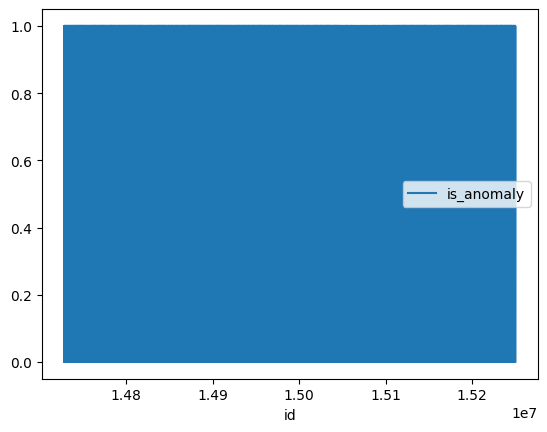

In [9]:
submission_df.plot("id", "is_anomaly")